<a href="https://colab.research.google.com/github/kishita21/MLDL/blob/main/EXP10/EXP10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659 (2.57 KB)

 Trainable params: 659 (2.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.4435 - val_loss: 0.2321
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1720 - val_loss: 0.1550
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1193 - val_loss: 0.1034
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0838 - val_loss: 0.0781
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0732 - val_loss: 0.0675
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0672 - val_loss: 0.0632
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0635 - val_loss: 0.0605
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0610 - val_loss: 0.0598
Epoch 9/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0598 - val_loss: 0.0566
Epoch 10/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0583 - val_loss: 0.0549
Epoch 11/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0565 - val_loss: 0.0550
Epoch 12/30
1750/1750 ━━━━━━━━

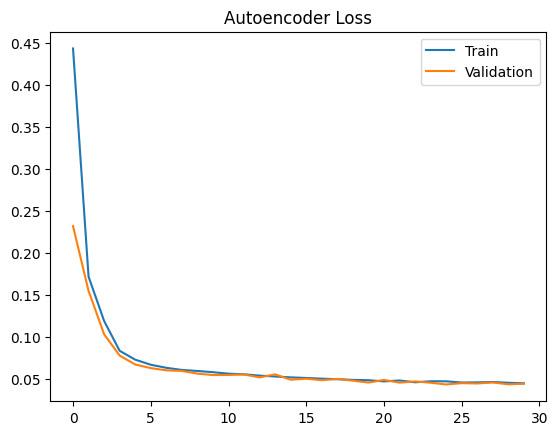

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step


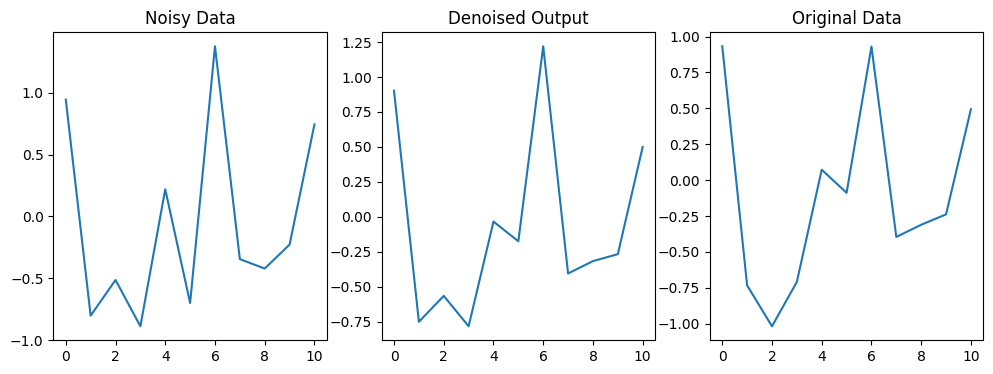

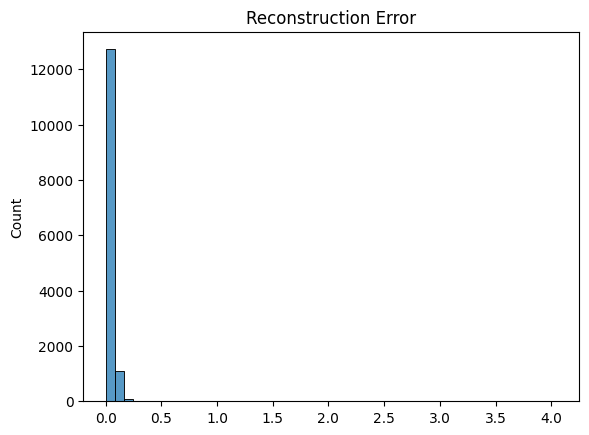

In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv('/content/cardio_train.csv', sep=';')

df = df.drop('id', axis=1)
df['age'] = df['age'] / 365

X = df.drop('cardio', axis=1)

# ==============================
# SCALE DATA
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 🔥 ADD NOISE (IMPORTANT)
# ==============================
noise_factor = 0.3
X_noisy = X_scaled + noise_factor * np.random.normal(size=X_scaled.shape)

# ==============================
# TRAIN TEST SPLIT
# ==============================
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)
X_train_noisy, X_test_noisy = train_test_split(X_noisy, test_size=0.2, random_state=42)

# ==============================
# AUTOENCODER MODEL
# ==============================
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)

# Decoder
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

# Model
autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

# ==============================
# TRAIN MODEL
# ==============================
history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_noisy, X_test)
)

# ==============================
# 📈 LOSS GRAPH
# ==============================
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Autoencoder Loss")
plt.legend(['Train','Validation'])
plt.show()

# ==============================
# 🔥 DENOISING RESULT
# ==============================
decoded_data = autoencoder.predict(X_test_noisy)

# ==============================
# 🎨 VISUALIZATION (IMPORTANT)
# ==============================

# Compare noisy vs reconstructed
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(X_test_noisy[0])
plt.title("Noisy Data")

plt.subplot(1,3,2)
plt.plot(decoded_data[0])
plt.title("Denoised Output")

plt.subplot(1,3,3)
plt.plot(X_test[0])
plt.title("Original Data")

plt.show()

# ==============================
# 🔥 ERROR DISTRIBUTION
# ==============================
error = np.mean(np.power(X_test - decoded_data, 2), axis=1)

sns.histplot(error, bins=50)
plt.title("Reconstruction Error")
plt.show()